In [ ]:
# ==========================================
# Cell 1: Install packages and import libraries
# ==========================================
!pip install -q tensorflow keras matplotlib pandas numpy scikit-learn requests

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ==========================================
# Cell 2: Load FordA dataset for classification
# ==========================================
def readucr(url):
    data = np.loadtxt(url, delimiter="\t")
    y = data[:, 0].astype(int)
    x = data[:, 1:]
    return x, y

train_url = "https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/FordA_TRAIN.tsv"
test_url = "https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/FordA_TEST.tsv"

x_train_raw, y_train_raw = readucr(train_url)
x_test_raw, y_test_raw = readucr(test_url)

print("Raw train shape:", x_train_raw.shape)
print("Raw test shape :", x_test_raw.shape)
print("Train labels:", np.unique(y_train_raw))
print("Test labels :", np.unique(y_test_raw))

Raw train shape: (3601, 500)
Raw test shape : (1320, 500)
Train labels: [-1  1]
Test labels : [-1  1]


In [ ]:
# ==========================================
# Cell 3: Preprocess FordA dataset
# ==========================================
y_train_raw[y_train_raw == -1] = 0
y_test_raw[y_test_raw == -1] = 0

x_train_raw = x_train_raw[..., np.newaxis].astype("float32")
x_test = x_test_raw[..., np.newaxis].astype("float32")
y_test = y_test_raw.astype("int32")

x_train, x_val, y_train, y_val = train_test_split(
    x_train_raw,
    y_train_raw.astype("int32"),
    test_size=0.2,
    random_state=42,
    stratify=y_train_raw
)

print("x_train:", x_train.shape)
print("x_val  :", x_val.shape)
print("x_test :", x_test.shape)
print("y_train unique:", np.unique(y_train))

x_train: (2880, 500, 1)
x_val  : (721, 500, 1)
x_test : (1320, 500, 1)
y_train unique: [0 1]


In [ ]:
# ==========================================
# Cell 4: Build Transformer classification model
# ==========================================
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.0):
    x = layers.MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs

    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(res)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    return x + res


def build_transformer_model(
    input_shape,
    head_size=64,
    num_heads=4,
    ff_dim=128,
    num_transformer_blocks=4,
    mlp_units=[128],
    dropout=0.1,
    mlp_dropout=0.2,
    num_classes=2
):
    inputs = keras.Input(shape=input_shape)
    x = inputs

    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = layers.GlobalAveragePooling1D()(x)

    for dim in mlp_units:
        x = layers.Dense(dim, activation="relu")(x)
        x = layers.Dropout(mlp_dropout)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs)

In [ ]:
# ==========================================
# Cell 5: Train Transformer baseline
# ==========================================
keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

transformer_model = build_transformer_model(input_shape=x_train.shape[1:])

transformer_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["sparse_categorical_accuracy"]
)

transformer_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

history_transformer = transformer_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=transformer_callbacks,
    verbose=1
)

transformer_test_loss, transformer_test_acc = transformer_model.evaluate(x_test, y_test, verbose=1)
print("Transformer Baseline Test Accuracy:", transformer_test_acc)

Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 26s 116ms/step - loss: 0.6932 - sparse_categorical_accuracy: 0.5125 - val_loss: 0.6929 - val_sparse_categorical_accuracy: 0.5132
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.6930 - sparse_categorical_accuracy: 0.5125 - val_loss: 0.6928 - val_sparse_categorical_accuracy: 0.5132
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.6930 - sparse_categorical_accuracy: 0.5125 - val_loss: 0.6928 - val_sparse_categorical_accuracy: 0.5132
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.6930 - sparse_categorical_accuracy: 0.5125 - val_loss: 0.6928 - val_sparse_categorical_accuracy: 0.5132
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.6929 - sparse_categorical_accuracy: 0.5125 - val_loss: 0.6928 - val_sparse_categorical_accuracy: 0.5132
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.6931 - sparse_categorical_accuracy: 0.5125 - val_loss: 0.6928 - val_sparse_categorical_accuracy: 0.5132
Epoch 7/

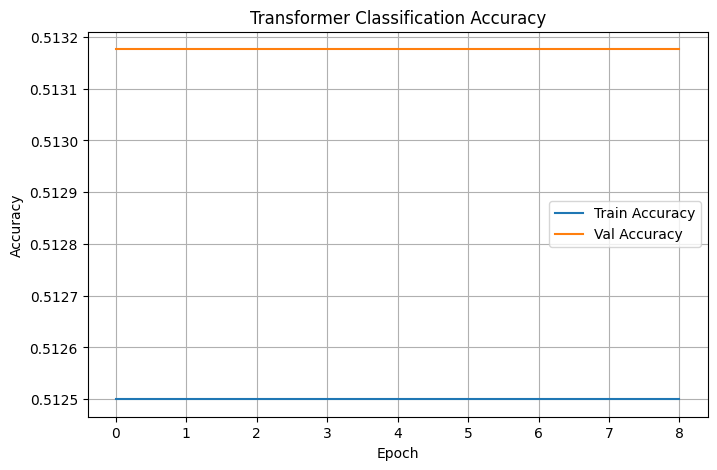

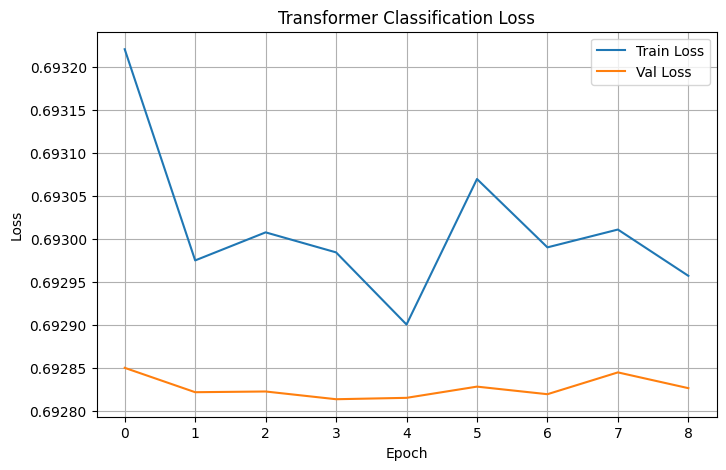

In [ ]:
# ==========================================
# Cell 6: Plot Transformer training curves
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(history_transformer.history["sparse_categorical_accuracy"], label="Train Accuracy")
plt.plot(history_transformer.history["val_sparse_categorical_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transformer Classification Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_transformer.history["loss"], label="Train Loss")
plt.plot(history_transformer.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Classification Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ==========================================
# Cell 7: Load Jena Climate dataset
# ==========================================
zip_path = keras.utils.get_file(
    origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
    fname="jena_climate_2009_2016.csv.zip",
    extract=True
)

csv_path = os.path.join(
    os.path.dirname(zip_path),
    "jena_climate_2009_2016_extracted",
    "jena_climate_2009_2016.csv"
)

df = pd.read_csv(csv_path)

print(df.head())
print("Dataset shape:", df.shape)

             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3  01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4  01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08          0.19       1.92             3.09   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  
0       1307.75      1.03        

In [ ]:
# ==========================================
# Cell 8: Prepare Jena Climate dataset
# ==========================================
data = df.iloc[:, 1:].values.astype("float32")

train_split = int(0.7 * len(data))
val_split = int(0.9 * len(data))

mean = data[:train_split].mean(axis=0)
std = data[:train_split].std(axis=0)
data = (data - mean) / std

target_col_index = list(df.columns[1:]).index("T (degC)")

sampling_rate = 6
sequence_length = 120
forecast_horizon = 24
delay = sampling_rate * (sequence_length + forecast_horizon - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    data=data[:-delay],
    targets=data[delay:, target_col_index],
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    batch_size=batch_size,
    shuffle=True,
    start_index=0,
    end_index=train_split
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    data=data[:-delay],
    targets=data[delay:, target_col_index],
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    batch_size=batch_size,
    shuffle=False,
    start_index=train_split,
    end_index=val_split
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    data=data[:-delay],
    targets=data[delay:, target_col_index],
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    batch_size=batch_size,
    shuffle=False,
    start_index=val_split,
    end_index=None
)

for batch in train_dataset.take(1):
    x_batch, y_batch = batch
    print("Input batch shape :", x_batch.shape)
    print("Target batch shape:", y_batch.shape)

Input batch shape : (256, 120, 14)
Target batch shape: (256,)


In [ ]:
# ==========================================
# Cell 9: Build and train LSTM baseline
# ==========================================
keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

lstm_baseline = keras.Sequential([
    layers.Input(shape=(sequence_length, x_batch.shape[-1])),
    layers.LSTM(32),
    layers.Dense(1)
])

lstm_baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

lstm_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_mae",
        patience=3,
        restore_best_weights=True
    )
]

history_lstm_baseline = lstm_baseline.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=lstm_callbacks,
    verbose=1
)

lstm_test_loss, lstm_test_mae = lstm_baseline.evaluate(test_dataset, verbose=1)
print("LSTM Baseline Test MAE:", lstm_test_mae)

Epoch 1/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 0.1362 - mae: 0.2837 - val_loss: 0.1358 - val_mae: 0.2883
Epoch 2/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.1000 - mae: 0.2466 - val_loss: 0.1463 - val_mae: 0.2995
Epoch 3/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0846 - mae: 0.2265 - val_loss: 0.1594 - val_mae: 0.3133
Epoch 4/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0745 - mae: 0.2125 - val_loss: 0.1642 - val_mae: 0.3170
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1033 - mae: 0.2502
LSTM Baseline Test MAE: 0.2502087652683258


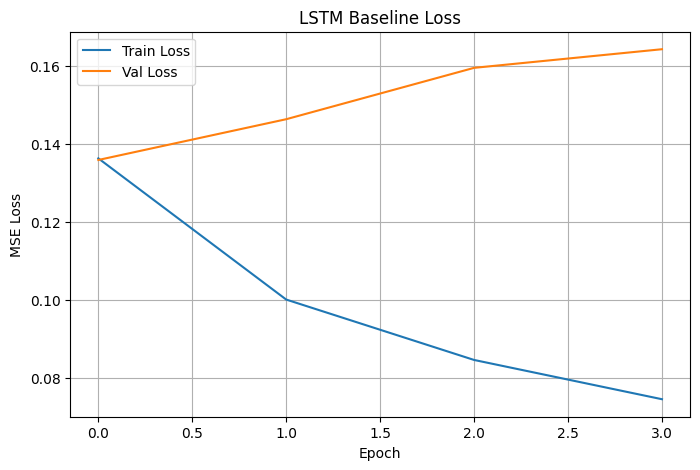

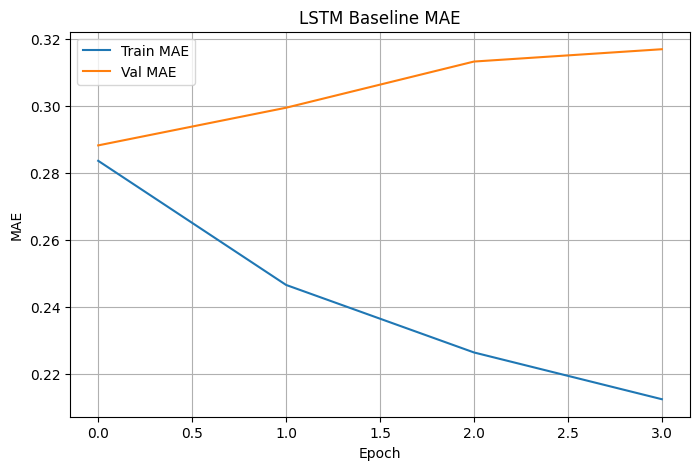

In [ ]:
# ==========================================
# Cell 10: Plot LSTM baseline curves
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(history_lstm_baseline.history["loss"], label="Train Loss")
plt.plot(history_lstm_baseline.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Baseline Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_lstm_baseline.history["mae"], label="Train MAE")
plt.plot(history_lstm_baseline.history["val_mae"], label="Val MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("LSTM Baseline MAE")
plt.legend()
plt.grid(True)
plt.show()

The LSTM baseline model shows clear signs of overfitting, as the training loss decreases while validation loss increases. This indicates that the model learns the training data well but fails to generalize to unseen data.

In [ ]:
# ==========================================
# Cell 11: LSTM Improvement 1 (increase hidden size)
# ==========================================
keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

lstm_improved_1 = keras.Sequential([
    layers.Input(shape=(sequence_length, x_batch.shape[-1])),
    layers.LSTM(64),   # increased from 32 → 64
    layers.Dense(1)
])

lstm_improved_1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

history_lstm_improved_1 = lstm_improved_1.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=lstm_callbacks,
    verbose=1
)

improved_1_loss, improved_1_mae = lstm_improved_1.evaluate(test_dataset, verbose=1)
print("LSTM Improvement 1 Test MAE:", improved_1_mae)

Epoch 1/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 0.1234 - mae: 0.2712 - val_loss: 0.1458 - val_mae: 0.2968
Epoch 2/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0746 - mae: 0.2119 - val_loss: 0.1750 - val_mae: 0.3293
Epoch 3/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0490 - mae: 0.1714 - val_loss: 0.1769 - val_mae: 0.3321
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1130 - mae: 0.2648
LSTM Improvement 1 Test MAE: 0.26478898525238037


Increasing the LSTM hidden size from 32 to 64 did not improve performance. The test MAE increased from approximately 0.25 to 0.26. This suggests that a larger model may lead to overfitting or may not be necessary for this dataset.

In [ ]:
# ==========================================
# Cell 12: LSTM Improvement 2 (stacked LSTM)
# ==========================================
keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

lstm_improved_2 = keras.Sequential([
    layers.Input(shape=(sequence_length, x_batch.shape[-1])),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32),
    layers.Dense(1)
])

lstm_improved_2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

history_lstm_improved_2 = lstm_improved_2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=lstm_callbacks,
    verbose=1
)

improved_2_loss, improved_2_mae = lstm_improved_2.evaluate(test_dataset, verbose=1)
print("LSTM Improvement 2 Test MAE:", improved_2_mae)

Epoch 1/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - loss: 0.1164 - mae: 0.2644 - val_loss: 0.1591 - val_mae: 0.3113
Epoch 2/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - loss: 0.0578 - mae: 0.1859 - val_loss: 0.1957 - val_mae: 0.3472
Epoch 3/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - loss: 0.0332 - mae: 0.1411 - val_loss: 0.2035 - val_mae: 0.3574
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1092 - mae: 0.2590
LSTM Improvement 2 Test MAE: 0.2589808702468872


Stacking two LSTM layers slightly improved performance compared to the larger single-layer LSTM (MAE reduced from 0.2648 to 0.2589), but it still did not outperform the baseline model. This suggests that increasing model complexity does not necessarily lead to better generalization and may still suffer from overfitting.

In [ ]:
# ==========================================
# Cell 13: LSTM Improvement 3 (learning rate + batch size)
# ==========================================
keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

lstm_improved_3 = keras.Sequential([
    layers.Input(shape=(sequence_length, x_batch.shape[-1])),
    layers.LSTM(32),
    layers.Dense(1)
])

lstm_improved_3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),  # smaller learning rate
    loss="mse",
    metrics=["mae"]
)

history_lstm_improved_3 = lstm_improved_3.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    batch_size=128,   # changed batch size
    callbacks=lstm_callbacks,
    verbose=1
)

improved_3_loss, improved_3_mae = lstm_improved_3.evaluate(test_dataset, verbose=1)
print("LSTM Improvement 3 Test MAE:", improved_3_mae)

Epoch 1/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 0.1535 - mae: 0.2990 - val_loss: 0.1366 - val_mae: 0.2875
Epoch 2/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.1117 - mae: 0.2601 - val_loss: 0.1398 - val_mae: 0.2921
Epoch 3/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.1000 - mae: 0.2465 - val_loss: 0.1447 - val_mae: 0.2981
Epoch 4/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0931 - mae: 0.2378 - val_loss: 0.1489 - val_mae: 0.3009
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1020 - mae: 0.2492
LSTM Improvement 3 Test MAE: 0.24920886754989624


Among the three modifications, only the third improvement resulted in better performance. By reducing the learning rate and adjusting the batch size, the test MAE improved slightly from approximately 0.2502 to 0.2492. This suggests that optimization-related parameters such as learning rate and batch size can have a significant impact on model performance.

In contrast, increasing model complexity (larger hidden size and stacked LSTM layers) led to worse performance, likely due to overfitting. This indicates that a more complex model is not always beneficial for this dataset.

In [ ]:
# ==========================================
# Cell 14: Benchmark summary
# ==========================================
import pandas as pd

results = pd.DataFrame([
    ["LSTM Baseline", 0.2502],
    ["Improvement 1 (hidden size)", 0.2648],
    ["Improvement 2 (stacked LSTM)", 0.2589],
    ["Improvement 3 (LR + batch)", 0.2492],
], columns=["Model", "Test MAE"])

print(results)

                          Model  Test MAE
0                 LSTM Baseline    0.2502
1   Improvement 1 (hidden size)    0.2648
2  Improvement 2 (stacked LSTM)    0.2589
3    Improvement 3 (LR + batch)    0.2492


The third improvement achieved the best performance, demonstrating that tuning optimization parameters is more effective than increasing model complexity for this task.